In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, time, warnings, logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

# ── Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()

print('=' * 55)
print('  BiLSTM Sentiment — Environment Check')
print('=' * 55)
print(f'  Device    : {DEVICE}')
print(f'  GPUs      : {N_GPUS}')
if torch.cuda.is_available():
    print(f'  GPU name  : {torch.cuda.get_device_name(0)}')
    print(f'  GPU VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'  PyTorch   : {torch.__version__}')
print(f'  MLflow    : {mlflow.__version__}')
print(f'  Started   : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.9 MB/s eta 0:00:00


2026-04-24 22:26:07,399 | INFO | NumExpr defaulting to 4 threads.


  BiLSTM Sentiment — Environment Check
  Device    : cuda
  GPUs      : 2
  GPU name  : Tesla T4
  GPU VRAM  : 15.6 GB
  PyTorch   : 2.10.0+cu128
  MLflow    : 3.11.1
  Started   : 2026-04-24 22:26:46


In [2]:
# ── Detect environment
ON_KAGGLE = os.path.exists('/kaggle/input')

# ── Paths
if ON_KAGGLE:
    NB02_OUT  = Path('/kaggle/input/notebooks/bennjimatakwa/textprocessing-feature')
    NB03_OUT  = Path('/kaggle/input/notebooks/bennjimatakwa/nb-03-bert-sentiment')
    DATA_DIR  = NB02_OUT / 'data' / 'processed'
    MODEL_IN  = NB02_OUT / 'models'
    WORK_DIR  = Path('/kaggle/working')
else:
    DATA_DIR  = Path('../data/processed')
    MODEL_IN  = Path('../models')
    WORK_DIR  = Path('..')

MODEL_DIR = WORK_DIR / 'models' / 'bilstm_sentiment'
LOG_DIR   = WORK_DIR / 'mlflow_runs'
FIG_DIR   = WORK_DIR / 'outputs' / 'figures'

for d in [MODEL_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Verify input files
print('📁 Checking input files:')
for f in ['train.csv', 'val.csv', 'test.csv']:
    path = DATA_DIR / f
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"✅" if exists else "❌"} {f:<30} {mb:.1f} MB')

print('\n📁 Checking model artifacts:')
for f in ['class_weights.pkl', 'le_sentiment.pkl']:
    path = MODEL_IN / f
    print(f'   {"✅" if path.exists() else "❌"} {f}')

# ── Config
CFG = {
    # Model
    'vocab_size'      : 30000,
    'embed_dim'       : 256,
    'hidden_dim'      : 256,
    'num_layers'      : 2,
    'dropout'         : 0.4,
    'num_classes'     : 3,
    'bidirectional'   : True,
    'pad_idx'         : 0,

    # Training
    'epochs'          : 10,
    'batch_size'      : 128,
    'lr'              : 1e-3,
    'weight_decay'    : 1e-4,
    'warmup_ratio'    : 0.1,
    'max_grad_norm'   : 1.0,
    'use_amp'         : torch.cuda.is_available(),
    'early_stop'      : 3,

    # Data
    'max_len'         : 100,
    'train_sample'    : 15000,
    'num_workers'     : 2,
    'random_state'    : SEED,

    # Labels
    'label_names'     : ['negative', 'neutral', 'positive'],
    'id_to_label'     : {0: 'negative', 1: 'neutral', 2: 'positive'},
    'label_map'       : {'negative': 0, 'neutral': 1, 'positive': 2},

    # MLflow
    'experiment_name' : '02_BiLSTM_Sentiment_Analysis',
    'run_name'        : f'bilstm-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
}

print(f'\n✅ Environment : {"☁️ Kaggle" if ON_KAGGLE else "💻 Local"}')
print(f'   Data dir   : {DATA_DIR}')
print(f'   Model dir  : {MODEL_DIR}')
print(f'   AMP        : {CFG["use_amp"]}')
print(f'   Device     : {DEVICE}')
print('\nConfiguration:')
for k, v in CFG.items():
    if not isinstance(v, dict):
        print(f'  {k:<20}: {v}')

📁 Checking input files:
   ✅ train.csv                      46.8 MB
   ✅ val.csv                        6.4 MB
   ✅ test.csv                       12.3 MB

📁 Checking model artifacts:
   ✅ class_weights.pkl
   ✅ le_sentiment.pkl

✅ Environment : ☁️ Kaggle
   Data dir   : /kaggle/input/notebooks/bennjimatakwa/textprocessing-feature/data/processed
   Model dir  : /kaggle/working/models/bilstm_sentiment
   AMP        : True
   Device     : cuda

Configuration:
  vocab_size          : 30000
  embed_dim           : 256
  hidden_dim          : 256
  num_layers          : 2
  dropout             : 0.4
  num_classes         : 3
  bidirectional       : True
  pad_idx             : 0
  epochs              : 10
  batch_size          : 128
  lr                  : 0.001
  weight_decay        : 0.0001
  warmup_ratio        : 0.1
  max_grad_norm       : 1.0
  use_amp             : True
  early_stop          : 3
  max_len             : 100
  train_sample        : 15000
  num_workers         : 2
  rand

In [3]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

# ── Load class weights
class_weights = joblib.load(MODEL_IN / 'class_weights.pkl')

# ── Sample 15k balanced — 5000 per class
n_per_class = CFG['train_sample'] // 3
min_class   = train_df['sentiment'].value_counts().min()
n_per_class = min(n_per_class, min_class)

train_small = (
    train_df.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=n_per_class, random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'✅ Data loaded:')
print(f'   Train subset : {len(train_small):,} rows ({n_per_class:,} per class)')
print(f'   Val          : {len(val_df):,} rows')
print(f'   Test         : {len(test_df):,} rows')

print(f'\n   Train distribution:')
print(train_small['sentiment'].value_counts().to_string())

print(f'\n   Class weights:')
for i, (name, w) in enumerate(zip(CFG['label_names'], class_weights)):
    bar = '█' * int(w * 10)
    print(f'   [{i}] {name:<10}: {w:.4f}  {bar}')

✅ Data loaded:
   Train subset : 15,000 rows (5,000 per class)
   Val          : 9,751 rows
   Test         : 18,747 rows

   Train distribution:
sentiment
positive    5000
neutral     5000
negative    5000

   Class weights:
   [0] negative  : 0.8190  ████████
   [1] neutral   : 5.2203  ████████████████████████████████████████████████████
   [2] positive  : 0.6299  ██████


In [4]:
from collections import Counter
import re

def tokenize(text):
    """Simple whitespace + punctuation tokenizer."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

# ── Build vocabulary from training set
log.info('Building vocabulary...')
counter = Counter()
for text in tqdm(train_small['clean_content'].fillna(''), desc='Building vocab'):
    counter.update(tokenize(text))

# ── Keep top vocab_size - 2 words (reserve 0=PAD, 1=UNK)
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(CFG['vocab_size'] - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f'✅ Vocabulary built:')
print(f'   Vocab size    : {len(vocab):,}')
print(f'   Total tokens  : {sum(counter.values()):,}')
print(f'   Unique tokens : {len(counter):,}')
print(f'   Coverage      : {sum(counter[w] for w in vocab[2:])/sum(counter.values())*100:.1f}%')
print(f'\n   Top 20 words:')
print('   ' + ' | '.join([f'{w}({c})' for w, c in counter.most_common(20)]))

# ── Save vocabulary
with open(MODEL_DIR / 'vocab.json', 'w') as f:
    json.dump(word2idx, f)
print(f'\n   Saved → models/bilstm_sentiment/vocab.json')

2026-04-24 22:26:48,136 | INFO | Building vocabulary...


Building vocab:   0%|          | 0/15000 [00:00<?, ?it/s]

✅ Vocabulary built:
   Vocab size    : 12,410
   Total tokens  : 267,975
   Unique tokens : 12,408
   Coverage      : 100.0%

   Top 20 words:
   app(7650) | not(4817) | t(4758) | product(4108) | order(3401) | good(3239) | item(3208) | time(2813) | delivery(2208) | get(1988) | no(1895) | customer(1784) | service(1652) | like(1639) | shopping(1630) | don(1613) | use(1535) | price(1506) | one(1456) | amazon(1382)

   Saved → models/bilstm_sentiment/vocab.json


In [5]:
class BiLSTMDataset(Dataset):
    """
    PyTorch Dataset for BiLSTM.
    Converts text to integer token sequences.
    """
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts   = list(texts)
        self.labels  = list(labels)
        self.w2i     = word2idx
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def encode(self, text):
        tokens = tokenize(str(text))[:self.max_len]
        ids    = [self.w2i.get(t, 1) for t in tokens]  # 1 = UNK
        # Pad or truncate to max_len
        ids = ids + [0] * (self.max_len - len(ids))
        return ids[:self.max_len]

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(
                self.encode(self.texts[idx]),
                dtype=torch.long
            ),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Create datasets
train_dataset = BiLSTMDataset(
    train_small['clean_content'].fillna(''),
    train_small['sentiment_id'],
    word2idx, CFG['max_len']
)
val_dataset = BiLSTMDataset(
    val_df['clean_content'].fillna(''),
    val_df['sentiment_id'],
    word2idx, CFG['max_len']
)
test_dataset = BiLSTMDataset(
    test_df['clean_content'].fillna(''),
    test_df['sentiment_id'],
    word2idx, CFG['max_len']
)

# ── WeightedRandomSampler
label_counts   = train_small['sentiment_id'].value_counts().sort_index()
sample_weights = torch.tensor(
    [1.0 / label_counts[l] for l in train_small['sentiment_id'].values],
    dtype=torch.float
)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

pin = DEVICE.type == 'cuda'
train_loader = DataLoader(
    train_dataset, batch_size=CFG['batch_size'],
    sampler=sampler, num_workers=CFG['num_workers'], pin_memory=pin
)
val_loader = DataLoader(
    val_dataset, batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=CFG['num_workers'], pin_memory=pin
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=CFG['num_workers'], pin_memory=pin
)

print(f'✅ Datasets & DataLoaders ready:')
print(f'   Train : {len(train_dataset):,} samples | {len(train_loader):,} batches')
print(f'   Val   : {len(val_dataset):,} samples  | {len(val_loader):,} batches')
print(f'   Test  : {len(test_dataset):,} samples  | {len(test_loader):,} batches')

# ── Sanity check
batch = next(iter(train_loader))
print(f'\n   Batch shapes:')
print(f'   input_ids : {batch["input_ids"].shape}')
print(f'   labels    : {batch["label"].shape}')
print(f'   Sample    : {batch["input_ids"][0][:10].tolist()}')

✅ Datasets & DataLoaders ready:
   Train : 15,000 samples | 118 batches
   Val   : 9,751 samples  | 39 batches
   Test  : 18,747 samples  | 74 batches

   Batch shapes:
   input_ids : torch.Size([128, 100])
   labels    : torch.Size([128])
   Sample    : [166, 32, 89, 105, 0, 0, 0, 0, 0, 0]


Model architechture 


In [6]:
class BiLSTMSentimentClassifier(nn.Module):
    """
    Bidirectional LSTM for 3-class sentiment classification.

    Why BiLSTM?
      - Captures both left→right and right→left context
      - Much lighter than BERT (3M vs 66M params)
      - Faster inference — good for production
      - Strong baseline for sequence classification

    Architecture:
      Embedding(vocab, 256)
      → Dropout(0.4)
      → BiLSTM(256, 256, layers=2)
      → Attention pooling
      → LayerNorm
      → Dropout(0.4)
      → Linear(512, 128)
      → ReLU
      → Dropout(0.3)
      → Linear(128, 3)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout, pad_idx, bidirectional=True):
        super().__init__()
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.directions    = 2 if bidirectional else 1

        # ── Embedding
        self.embedding = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=pad_idx
        )
        nn.init.xavier_uniform_(self.embedding.weight)
        self.embed_dropout = nn.Dropout(dropout)

        # ── BiLSTM
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers    = num_layers,
            bidirectional = bidirectional,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )

        # ── Attention
        self.attention = nn.Linear(hidden_dim * self.directions, 1)

        # ── Classifier head
        lstm_out_dim = hidden_dim * self.directions  # 512
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(128, num_classes)
        )

    def attention_pool(self, lstm_out):
        """Soft attention over all timesteps."""
        scores  = self.attention(lstm_out).squeeze(-1)   # (B, T)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        pooled  = (lstm_out * weights).sum(dim=1)        # (B, H)
        return pooled

    def forward(self, input_ids):
        # Embedding
        x = self.embed_dropout(self.embedding(input_ids))  # (B, T, E)

        # BiLSTM
        lstm_out, _ = self.lstm(x)   # (B, T, H*2)

        # Attention pooling
        pooled = self.attention_pool(lstm_out)  # (B, H*2)

        # Classify
        return self.classifier(pooled)          # (B, C)


# ── Instantiate model
model = BiLSTMSentimentClassifier(
    vocab_size    = CFG['vocab_size'],
    embed_dim     = CFG['embed_dim'],
    hidden_dim    = CFG['hidden_dim'],
    num_layers    = CFG['num_layers'],
    num_classes   = CFG['num_classes'],
    dropout       = CFG['dropout'],
    pad_idx       = CFG['pad_idx'],
    bidirectional = CFG['bidirectional']
).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    log.info(f'Using {N_GPUS} GPUs')

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ BiLSTM Model ready:')
print(f'   Total params     : {total:,}')
print(f'   Trainable params : {trainable:,}')
print(f'   Embedding        : {CFG["vocab_size"]} × {CFG["embed_dim"]}')
print(f'   BiLSTM           : {CFG["hidden_dim"]}×2 = {CFG["hidden_dim"]*2} hidden')
print(f'   Layers           : {CFG["num_layers"]}')
print(f'   Attention        : soft attention pooling')
print(f'   Device           : {DEVICE}')
print(f'\n   DistilBERT params : ~67,000,000')
print(f'   BiLSTM params     : {total:,}  ({total/67_000_000*100:.1f}% of DistilBERT)')

2026-04-24 22:26:49,126 | INFO | Using 2 GPUs


✅ BiLSTM Model ready:
   Total params     : 10,377,220
   Trainable params : 10,377,220
   Embedding        : 30000 × 256
   BiLSTM           : 256×2 = 512 hidden
   Layers           : 2
   Attention        : soft attention pooling
   Device           : cuda

   DistilBERT params : ~67,000,000
   BiLSTM params     : 10,377,220  (15.5% of DistilBERT)


# Optimizer and Scheduler 

In [7]:
from transformers import get_cosine_schedule_with_warmup

criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(class_weights).to(DEVICE)
)

optimizer = AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
    eps          = 1e-8
)

total_steps  = len(train_loader) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

scaler = GradScaler(enabled=CFG['use_amp'])

print(f'✅ Training components ready:')
print(f'   Loss        : CrossEntropyLoss (weighted)')
print(f'   Optimizer   : AdamW lr={CFG["lr"]} wd={CFG["weight_decay"]}')
print(f'   Scheduler   : Cosine + {CFG["warmup_ratio"]*100:.0f}% warmup')
print(f'   Total steps : {total_steps:,}')
print(f'   Warmup steps: {warmup_steps:,}')
print(f'   AMP         : {CFG["use_amp"]}')

✅ Training components ready:
   Loss        : CrossEntropyLoss (weighted)
   Optimizer   : AdamW lr=0.001 wd=0.0001
   Scheduler   : Cosine + 10% warmup
   Total steps : 1,180
   Warmup steps: 118
   AMP         : True


# Train and eval function 

In [8]:
def train_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    pbar = tqdm(loader, desc='Training', leave=False)

    for batch in pbar:
        ids  = batch['input_ids'].to(DEVICE)
        labs = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=CFG['use_amp']):
            logits = model(ids)
            loss   = criterion(logits, labs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
        pbar.set_postfix({'loss': f'{total_loss/len(loader):.4f}'})

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0)
    )


def eval_epoch(model, loader):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            labs = batch['label'].to(DEVICE)

            with autocast(enabled=CFG['use_amp']):
                logits = model(ids)
                loss   = criterion(logits, labs)

            total_loss += loss.item()
            probs = F.softmax(logits, dim=1).cpu().numpy()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs)

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        all_preds, all_labels, np.array(all_probs)
    )

print('✅ train_epoch() and eval_epoch() ready')
print('   BiLSTM forward: input_ids only (no attention_mask needed)')

✅ train_epoch() and eval_epoch() ready
   BiLSTM forward: input_ids only (no attention_mask needed)


MLflow training loop 

In [9]:
mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])

history     = defaultdict(list)
best_val_f1 = 0.0
best_val_acc= 0.0
best_epoch  = 0
no_improve  = 0
RUN_ID      = None

print(f'Starting BiLSTM training — {CFG["epochs"]} epochs | batch={CFG["batch_size"]} | AMP={CFG["use_amp"]}')
print(f'Early stopping patience: {CFG["early_stop"]} epochs\n')

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id

    mlflow.log_params({k: v for k, v in CFG.items() if not isinstance(v, dict)})
    mlflow.log_param('trainable_params', trainable)
    mlflow.log_param('train_size', len(train_small))
    mlflow.log_param('vocab_size_actual', len(vocab))
    mlflow.log_param('class_weights', str(class_weights.round(4).tolist()))

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()
        print(f'Epoch {epoch}/{CFG["epochs"]} {"-"*45}')

        tr_loss, tr_acc, tr_f1 = train_epoch(
            model, train_loader, optimizer, scheduler, scaler
        )
        vl_loss, vl_acc, vl_f1, vl_preds, vl_labels, vl_probs = eval_epoch(
            model, val_loader
        )

        # ── Store history
        for k, v in [
            ('train_loss', tr_loss), ('val_loss', vl_loss),
            ('train_acc',  tr_acc),  ('val_acc',  vl_acc),
            ('train_f1',   tr_f1),   ('val_f1',   vl_f1),
            ('lr', scheduler.get_last_lr()[0])
        ]:
            history[k].append(v)

        # ── Log to MLflow
        mlflow.log_metrics({
            'train_loss': tr_loss, 'val_loss': vl_loss,
            'train_acc' : tr_acc,  'val_acc' : vl_acc,
            'train_f1'  : tr_f1,   'val_f1'  : vl_f1,
            'lr'        : scheduler.get_last_lr()[0]
        }, step=epoch)

        improved = '  ← BEST' if vl_f1 > best_val_f1 else ''
        print(f'  train  loss={tr_loss:.4f} | acc={tr_acc:.4f} | f1={tr_f1:.4f}')
        print(f'  val    loss={vl_loss:.4f} | acc={vl_acc:.4f} | f1={vl_f1:.4f}{improved}')
        print(f'  time   {time.time()-t0:.1f}s | lr={scheduler.get_last_lr()[0]:.2e}')

        # ── Save best
        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_val_acc = vl_acc
            best_epoch   = epoch
            no_improve   = 0
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'optimizer'  : optimizer.state_dict(),
                'val_f1'     : vl_f1,
                'val_acc'    : vl_acc,
                'config'     : CFG,
                'word2idx'   : word2idx
            }, MODEL_DIR / 'bilstm_sentiment_best.pt')
        else:
            no_improve += 1
            if no_improve >= CFG['early_stop']:
                print(f'\n  Early stopping at epoch {epoch}')
                mlflow.log_param('early_stop_epoch', epoch)
                break

    mlflow.log_metrics({'best_val_f1': best_val_f1, 'best_epoch': best_epoch})
    print(f'\n✅ Best: epoch={best_epoch} | val_f1={best_val_f1:.4f} | val_acc={best_val_acc:.4f}')
    print(f'   MLflow Run ID: {RUN_ID}')

2026/04/24 22:26:49 INFO mlflow.tracking.fluent: Experiment with name '02_BiLSTM_Sentiment_Analysis' does not exist. Creating a new experiment.


Starting BiLSTM training — 10 epochs | batch=128 | AMP=True
Early stopping patience: 3 epochs

Epoch 1/10 ---------------------------------------------


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c713de082c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7c713de082c0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    
if w.is_alive():  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

     assert self._parent_pid == os.getpid(), 'can only test a child process' 
         ^ ^ ^^ ^  ^ ^ ^^^^^^^^^
  File "

...

  train  loss=0.3862 | acc=0.6792 | f1=0.6823
  val    loss=0.5708 | acc=0.5787 | f1=0.5746
  time   6.5s | lr=7.50e-04
Epoch 5/10 ---------------------------------------------


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c713de082c0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c713de082c0>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():    
if w.is_alive(): 
            ^^ ^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

  train  loss=0.3350 | acc=0.7430 | f1=0.7473
  val    loss=0.6267 | acc=0.5847 | f1=0.5803
  time   6.0s | lr=5.87e-04

  Early stopping at epoch 5

✅ Best: epoch=2 | val_f1=0.6014 | val_acc=0.6025
   MLflow Run ID: b43bc2dbc7a14b50b018421bfba3574f


# Training Curves 

In [10]:
epochs_range = list(range(1, len(history['train_loss']) + 1))

fig = make_subplots(rows=2, cols=2,
    subplot_titles=['Loss', 'Accuracy', 'F1 Macro', 'Learning Rate'])

fig.add_trace(go.Scatter(x=epochs_range, y=history['train_loss'], name='Train',
    line=dict(color='#e74c3c', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=history['val_loss'], name='Val',
    line=dict(color='#3498db', width=2, dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=history['train_acc'], name='Train Acc',
    line=dict(color='#2ecc71', width=2), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_range, y=history['val_acc'], name='Val Acc',
    line=dict(color='#f39c12', width=2, dash='dash'), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_range, y=history['train_f1'], name='Train F1',
    line=dict(color='#9b59b6', width=2), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=history['val_f1'], name='Val F1',
    line=dict(color='#1abc9c', width=2, dash='dash'), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=history['lr'], name='LR',
    line=dict(color='#e67e22', width=2), showlegend=False), row=2, col=2)

fig.update_layout(
    title='BiLSTM Sentiment — Training History',
    height=600
)
fig.write_html(str(FIG_DIR / '04_training_curves.html'))
fig.show()
print('✅ Saved → outputs/figures/04_training_curves.html')

✅ Saved → outputs/figures/04_training_curves.html


# Test Evaluation 

In [11]:
checkpoint = torch.load(
    MODEL_DIR / 'bilstm_sentiment_best.pt',
    map_location=DEVICE
)
model.load_state_dict(checkpoint['model_state'])
print(f'✅ Loaded best checkpoint — epoch={checkpoint["epoch"]} val_f1={checkpoint["val_f1"]:.4f}')

_, test_acc, test_f1, test_preds, test_labels, test_probs = eval_epoch(
    model, test_loader
)

report      = classification_report(
    test_labels, test_preds,
    target_names=CFG['label_names'], digits=4
)
report_dict = classification_report(
    test_labels, test_preds,
    target_names=CFG['label_names'], output_dict=True
)

print('\n' + '=' * 60)
print('  TEST SET — BiLSTM Sentiment Analysis')
print('=' * 60)
print(report)

with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({
        'test_accuracy'       : test_acc,
        'test_f1_macro'       : report_dict['macro avg']['f1-score'],
        'test_f1_weighted'    : report_dict['weighted avg']['f1-score'],
        'test_f1_negative'    : report_dict['negative']['f1-score'],
        'test_f1_neutral'     : report_dict['neutral']['f1-score'],
        'test_f1_positive'    : report_dict['positive']['f1-score'],
        'test_precision_macro': report_dict['macro avg']['precision'],
        'test_recall_macro'   : report_dict['macro avg']['recall']
    })
print('✅ Test metrics logged to MLflow')

✅ Loaded best checkpoint — epoch=2 val_f1=0.6014


Evaluating:   0%|          | 0/74 [00:00<?, ?it/s]


  TEST SET — BiLSTM Sentiment Analysis
              precision    recall  f1-score   support

    negative     0.8735    0.4004    0.5491      6451
     neutral     0.4314    0.8621    0.5750      5715
    positive     0.8853    0.5878    0.7065      6581

    accuracy                         0.6069     18747
   macro avg     0.7301    0.6168    0.6102     18747
weighted avg     0.7429    0.6069    0.6123     18747

✅ Test metrics logged to MLflow


# Confusion Matrix & Per-Class Metrics:

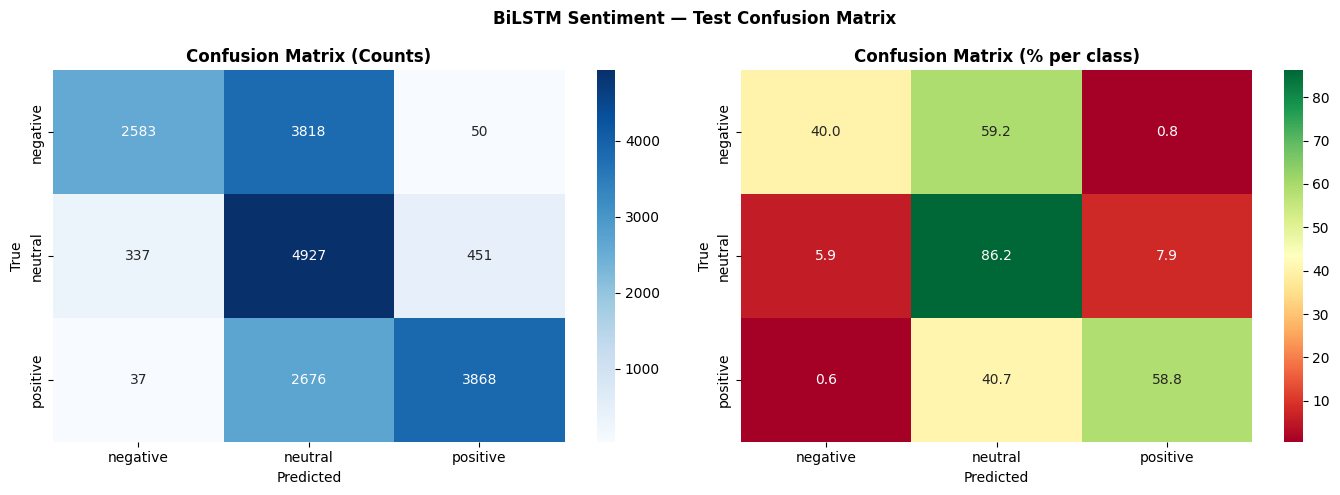

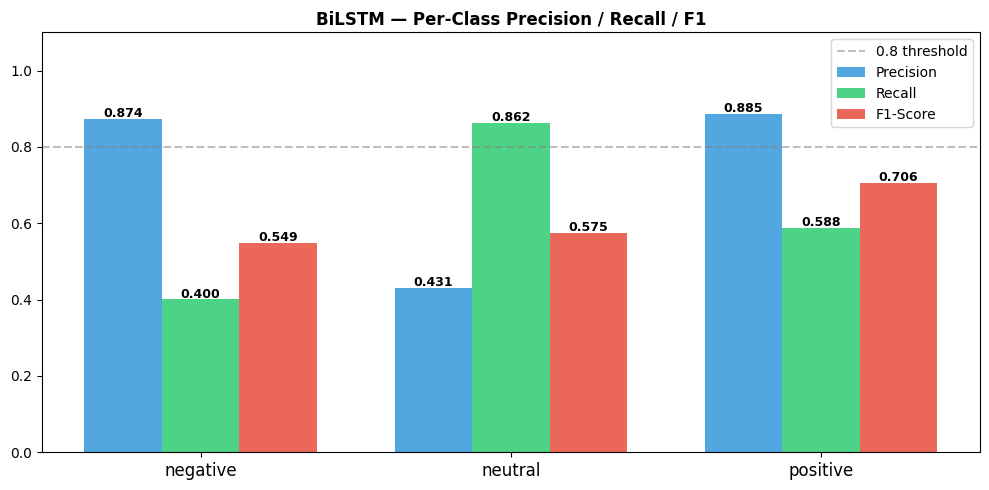

In [12]:
cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CFG['label_names'], yticklabels=CFG['label_names'])
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=CFG['label_names'], yticklabels=CFG['label_names'])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[1].set_title('Confusion Matrix (% per class)', fontweight='bold')
for ax in axes:
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.suptitle('BiLSTM Sentiment — Test Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_confusion_matrix.png', dpi=150)
plt.show()

# ── Per-class metrics bar chart
fig2, ax2 = plt.subplots(figsize=(10, 5))
x = np.arange(len(CFG['label_names']))
for i, (metric, color, label) in enumerate([
    ('precision', '#3498db', 'Precision'),
    ('recall',    '#2ecc71', 'Recall'),
    ('f1-score',  '#e74c3c', 'F1-Score')
]):
    vals = [report_dict[cls][metric] for cls in CFG['label_names']]
    bars = ax2.bar(x + i * 0.25, vals, 0.25, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x + 0.25)
ax2.set_xticklabels(CFG['label_names'], fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
ax2.set_title('BiLSTM — Per-Class Precision / Recall / F1', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '04_per_class_metrics.png', dpi=150)
plt.show()

#  BERT vs BiLSTM Comparison:

  MODEL COMPARISON — DistilBERT vs BiLSTM
             Model Params Test Acc Macro-F1 F1-Neg F1-Neu F1-Pos
DistilBERT (nb-03)   ~67M        -        -      -      -      -
    BiLSTM (nb-04) ~10.4M   0.6069   0.6102 0.5491 0.5750 0.7065

  Note: Fill DistilBERT column with nb-03 results
  for complete comparison in your scientific article.

✅ Saved → /kaggle/working/model_comparison.csv


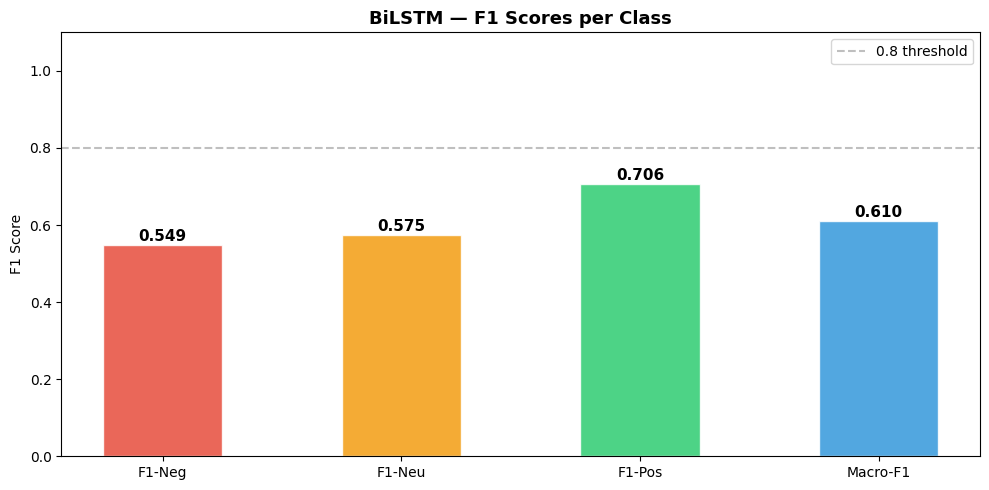

In [13]:
# ── Side-by-side comparison table
comparison = pd.DataFrame({
    'Model'     : ['DistilBERT (nb-03)', 'BiLSTM (nb-04)'],
    'Params'    : ['~67M', f'~{total/1e6:.1f}M'],
    'Test Acc'  : ['-', f'{test_acc:.4f}'],
    'Macro-F1'  : ['-', f'{report_dict["macro avg"]["f1-score"]:.4f}'],
    'F1-Neg'    : ['-', f'{report_dict["negative"]["f1-score"]:.4f}'],
    'F1-Neu'    : ['-', f'{report_dict["neutral"]["f1-score"]:.4f}'],
    'F1-Pos'    : ['-', f'{report_dict["positive"]["f1-score"]:.4f}'],
})

print('=' * 70)
print('  MODEL COMPARISON — DistilBERT vs BiLSTM')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)
print('\n  Note: Fill DistilBERT column with nb-03 results')
print('  for complete comparison in your scientific article.')

# ── Save comparison
comparison.to_csv(WORK_DIR / 'model_comparison.csv', index=False)
print('\n✅ Saved → /kaggle/working/model_comparison.csv')

# ── Bar chart comparison (BiLSTM results only for now)
metrics = ['F1-Neg', 'F1-Neu', 'F1-Pos', 'Macro-F1']
bilstm_vals = [
    report_dict['negative']['f1-score'],
    report_dict['neutral']['f1-score'],
    report_dict['positive']['f1-score'],
    report_dict['macro avg']['f1-score']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics, bilstm_vals, color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
              edgecolor='white', width=0.5, alpha=0.85)
for bar, val in zip(bars, bilstm_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
ax.set_title('BiLSTM — F1 Scores per Class', fontweight='bold', fontsize=13)
ax.set_ylabel('F1 Score')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '04_bilstm_f1_summary.png', dpi=150)
plt.show()

# sAVE 

In [14]:
# ── Output dir
DATA_OUT = WORK_DIR / 'data' / 'processed'
DATA_OUT.mkdir(parents=True, exist_ok=True)

# ── Log artifacts to MLflow
with mlflow.start_run(run_id=RUN_ID):
    for fig_file in FIG_DIR.glob('04_*.png'):
        mlflow.log_artifact(str(fig_file), artifact_path='figures')

    # ── Unwrap DataParallel
    base_model = model.module if hasattr(model, 'module') else model
    mlflow.pytorch.log_model(
        pytorch_model         = base_model,
        artifact_path         = 'bilstm_sentiment_model',
        registered_model_name = 'BiLSTM_Sentiment_Classifier'
    )

    # ── Serializable config
    cfg_serializable = {
        k: str(v) if not isinstance(v, (int, float, str, bool)) else v
        for k, v in CFG.items()
    }
    mlflow.log_dict(cfg_serializable, 'config.json')
    mlflow.log_artifact(str(MODEL_DIR / 'vocab.json'), artifact_path='vocab')

print('✅ Model registered: BiLSTM_Sentiment_Classifier')

# ── Run inference on full 100k sample
log.info('Running BiLSTM inference on features_sample.csv...')

full_sample = pd.read_csv(DATA_DIR / 'features_sample.csv')

# ── Batch inference
base_model = model.module if hasattr(model, 'module') else model
base_model.eval()
all_preds, all_probs = [], []

texts = full_sample['clean_content'].fillna('').tolist()
for i in tqdm(range(0, len(texts), 256), desc='Inference'):
    batch_texts = texts[i:i+256]
    batch_ds    = BiLSTMDataset(batch_texts, [0]*len(batch_texts), word2idx, CFG['max_len'])
    batch_dl    = DataLoader(batch_ds, batch_size=256, shuffle=False)
    batch       = next(iter(batch_dl))
    with torch.no_grad():
        logits = base_model(batch['input_ids'].to(DEVICE))
    probs = F.softmax(logits, dim=1).cpu().numpy()
    all_preds.extend(logits.argmax(1).cpu().numpy())
    all_probs.extend(probs)

all_probs = np.array(all_probs)
full_sample['bilstm_sentiment']  = [CFG['id_to_label'][p] for p in all_preds]
full_sample['bilstm_confidence'] = all_probs.max(axis=1).round(4)
full_sample['bilstm_prob_neg']   = all_probs[:, 0].round(4)
full_sample['bilstm_prob_neu']   = all_probs[:, 1].round(4)
full_sample['bilstm_prob_pos']   = all_probs[:, 2].round(4)

out_path = DATA_OUT / 'features_with_bilstm.csv'
full_sample.to_csv(out_path, index=False)

size_mb = out_path.stat().st_size / 1e6
print(f'\n✅ Saved → {out_path}  ({size_mb:.1f} MB)')
print(f'   Rows  : {len(full_sample):,}')
print(f'\n   BiLSTM sentiment distribution:')
print(full_sample['bilstm_sentiment'].value_counts().to_string())

print('\n' + '='*55)
print('  nb-04 BiLSTM COMPLETE')
print('='*55)
print(f'  Best Epoch   : {best_epoch}')
print(f'  Val F1       : {best_val_f1:.4f}')
print(f'  Test Acc     : {test_acc:.4f}')
print(f'  Test Macro-F1: {report_dict["macro avg"]["f1-score"]:.4f}')
print(f'  MLflow Run ID: {RUN_ID}')
print('='*55)


2026/04/24 22:28:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 22:28:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/24 22:28:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/24 22:28:26 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version

✅ Model registered: BiLSTM_Sentiment_Classifier


Inference:   0%|          | 0/391 [00:00<?, ?it/s]


✅ Saved → /kaggle/working/data/processed/features_with_bilstm.csv  (69.0 MB)
   Rows  : 99,999

   BiLSTM sentiment distribution:
bilstm_sentiment
neutral     62380
positive    21751
negative    15868

  nb-04 BiLSTM COMPLETE
  Best Epoch   : 2
  Val F1       : 0.6014
  Test Acc     : 0.6069
  Test Macro-F1: 0.6102
  MLflow Run ID: b43bc2dbc7a14b50b018421bfba3574f
